# 신경망 없이 MNIST 숫자 분류
출처: https://www.kaggle.com/code/dhconnelly/mnist-without-neural-nets

# 전체 그림

- 이것은 28x28 픽셀 배열(훈련 및 테스트 세트에서 "pixel0"부터 "pixel783"까지 저장됨)을 기반으로 클래스 0부터 9까지를 예측하려는 다중 클래스 분류 문제입니다. 각 픽셀은 0에서 255 사이의 값을 가집니다. [지침](https://www.kaggle.com/competitions/digit-recognizer)에 따라 평가 지표는 정확도이므로 이를 사용할 것입니다.
- 신경망 기반 솔루션을 피하고 대신 [확률적 경사 하강법](https://scikit-learn.org/stable/modules/sgd.html), [k-최근접 이웃](https://scikit-learn.org/stable/modules/neighbors.html#classification), [그래디언트 부스팅 트리](https://xgboost.readthedocs.io/en/stable/tutorials/model.html)를 훈련하고 비교합니다.
- 테스트 세트에서 97% 분류 정확도를 목표로 합니다.

In [1]:
import multiprocessing
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn import model_selection, linear_model, metrics, neighbors
import xgboost as xgb

# 데이터 가져오기 및 구조 이해

In [2]:
def load_data(path):
    # .npz 파일 로드
    mnist_train = np.load(path)
    
    # 저장된 키를 사용하여 배열 액세스
    X_train_images = mnist_train['train_images']
    y_train_labels = mnist_train['train_labels']
    
    # 이미지를 28x28에서 784로 평탄화
    train_images_flat = X_train_images.reshape(X_train_images.shape[0], -1)
    
    # 레이블을 첫 번째 열로, 그 다음 픽셀 열로 DataFrame 생성
    data = pd.DataFrame(train_images_flat)
    data.insert(0, 'label', y_train_labels)
    data.index += 1
    
    return data

data = load_data("../assets/mnist_train.npz")

In [3]:
data.shape

(60000, 785)

In [4]:
data.head()

,label,0,1,2,3,4,5,6,7,8,...,774,775,776,777,778,779,780,781,782,783
1,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
data.describe()

,label,0,1,2,3,4,5,6,7,8,...,774,775,776,777,778,779,780,781,782,783
count,60000.000000,60000.0,60000.0,60000.0,60000.0,60000.0,60000.0,60000.0,60000.0,60000.0,...,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.0000,60000.0,60000.0,60000.0,60000.0
mean,4.453933,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.200433,0.088867,0.045633,0.019283,0.015117,0.0020,0.0,0.0,0.0,0.0
std,2.889270,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,6.042472,3.956189,2.839845,1.686770,1.678283,0.3466,0.0,0.0,0.0,0.0
min,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.0,0.0,0.0,0.0
25%,2.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.0,0.0,0.0,0.0
50%,4.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.0,0.0,0.0,0.0
75%,7.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.0,0.0,0.0,0.0
max,9.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,254.000000,254.000000,253.000000,253.000000,254.000000,62.0000,0.0,0.0,0.0,0.0


In [6]:
# null 데이터 없음
assert pd.isnull(data).any().sum() == 0

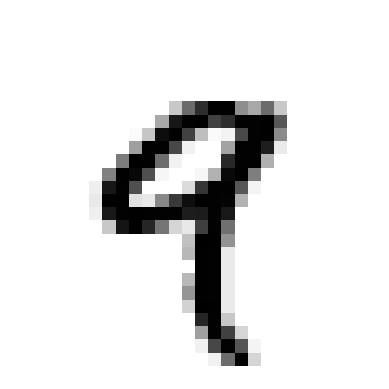

In [7]:
# 행은 그레이스케일 비트맵

def plot_digit(row):
    image = row[1:].to_numpy().reshape(28, 28)
    plt.imshow(image, cmap="binary")
    plt.axis("off")
    plt.show()

plot_digit(data[data["label"] == 9].iloc[0])

In [8]:
# 유효한 비트만, 0-9 레이블만
assert list(np.unique(data.values)) == list(range(256))
assert list(np.unique(data["label"].values)) == list(range(10))

# 테스트 세트 생성

In [9]:
test_size = 0.2
train, test = model_selection.train_test_split(data, test_size=test_size, random_state=19)

def split_Xy(data):
    return data.iloc[:, 1:], data.iloc[:, 0]

X_train, y_train = split_Xy(train)
X_test, y_test = split_Xy(test)

# 데이터 탐색 및 통찰 발견

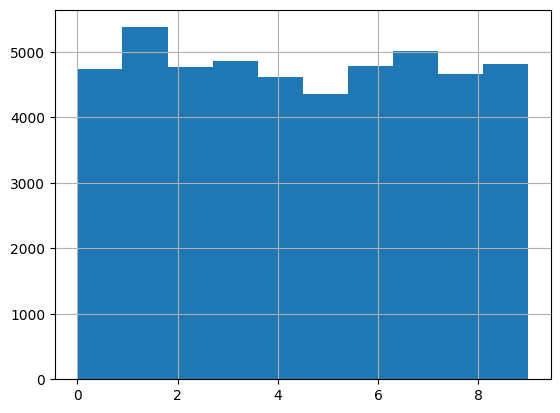

In [10]:
# 레이블이 균형을 이루고 있나요?
y_train.hist()
plt.show()
# 꽤 균형이 잡혀 있습니다!

# 모델 선택 및 훈련

In [11]:
clfs = {
    "sgd": linear_model.SGDClassifier(random_state=19, n_jobs=2),
    "xgb": xgb.XGBClassifier(random_state=19, tree_method="hist", device="cuda"), #xgb.XGBClassifier(random_state=19, tree_method="hist"),  # "gpu_hist"에서 "hist"로 변경
    "knn": neighbors.KNeighborsClassifier(n_jobs=2),
}

In [12]:
# 모델 전반에 걸쳐 교차 검증 및 훈련 정확도 점수 계산

def crossval(clf):
    return model_selection.cross_val_score(
        clf, X_train, y_train, cv=3, scoring="accuracy", verbose=2, n_jobs=2)

def crossval_all(clfs):
    cv_scores = {}
    for name, clf in clfs.items():
        print(f"{name} 평가 중...")
        begin = time.perf_counter()
        cv_scores[name] = crossval(clf)
        end = time.perf_counter()
        print(f"{name} 평가 완료 ({end-begin:.2f}초)")
    return cv_scores

def score(clf):
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_train)
    return metrics.accuracy_score(y_train, y_pred)

def score_all(clfs):
    train_scores = {}
    for name, clf in clfs.items():
        print(f"{name} 피팅 중...")
        begin = time.perf_counter()
        train_scores[name] = score(clf)
        end = time.perf_counter()
        print(f"{name} 피팅 완료 ({end-begin:.2f}초)")
    return train_scores

def evaluate_all(clfs):
    train_scores = score_all(clfs)
    cv_scores = crossval_all(clfs)
    print(f"모델\t훈련\t교차검증")
    for name in clfs:
        train_acc, cv_acc = train_scores[name], cv_scores[name].mean()
        print(f"{name}\t{train_acc:0.2f}\t{cv_acc:0.2f}")

In [13]:
evaluate_all(clfs)

sgd 피팅 중...
sgd 피팅 완료 (41.81초)
xgb 피팅 중...
sgd 피팅 완료 (41.81초)
xgb 피팅 중...


c:\Users\lota\Documents\SourceCodes\ML_25_2\.venv\Lib\site-packages\xgboost\core.py:774: UserWarning: [11:56:19] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


xgb 피팅 완료 (12.60초)
knn 피팅 중...
knn 피팅 완료 (50.40초)
sgd 평가 중...
knn 피팅 완료 (50.40초)
sgd 평가 중...


[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done   3 out of   3 | elapsed:   54.4s finished
[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done   3 out of   3 | elapsed:   54.4s finished
[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.


sgd 평가 완료 (54.63초)
xgb 평가 중...


[Parallel(n_jobs=2)]: Done   3 out of   3 | elapsed:   28.4s finished
[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.


xgb 평가 완료 (28.57초)
knn 평가 중...
knn 평가 완료 (28.24초)
모델	훈련	교차검증
sgd	0.90	0.88
xgb	1.00	0.97
knn	0.98	0.97
knn 평가 완료 (28.24초)
모델	훈련	교차검증
sgd	0.90	0.88
xgb	1.00	0.97
knn	0.98	0.97


[Parallel(n_jobs=2)]: Done   3 out of   3 | elapsed:   28.0s finished


## 생각

xgboost는 잘 수행되고 있습니다 - 100% 훈련 정확도와 평균 교차 검증 정확도 약 96.9%로, 편향이 매우 낮습니다. 하지만 분산이 우리가 원하는 것보다 약간 높습니다. 테스트 세트에서 97% 정확도를 목표로 하기 때문입니다. 미세 조정에서 이를 개선할 수 있는지 봅시다.

knn도 잘 수행되고 있으며, 분산이 더 낮습니다. 이것도 미세 조정을 시도해 봅시다.

# 모델 미세 조정

In [14]:
# knn의 k에 대해 미세 조정

knn_search = model_selection.GridSearchCV(
    clfs["knn"],
    param_grid={ "n_neighbors": [3, 4, 5, 6], "weights": ["uniform", "distance"] },
    scoring="accuracy",
    cv=3, n_jobs=2, verbose=2
)

knn_search.fit(X_train, y_train)
print(knn_search.best_params_)
print(knn_search.best_score_)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
{'n_neighbors': 4, 'weights': 'distance'}
0.9702708333333333
{'n_neighbors': 4, 'weights': 'distance'}
0.9702708333333333


In [15]:
# xgboost를 미세 조정하여 분산 감소

xgb_search = model_selection.GridSearchCV(
    clfs["xgb"],
    param_grid={ "gamma": [0.0, 0.01, 0.1, 1.0],  },
    scoring="accuracy",
    cv=3, n_jobs=2, verbose=2,
)

xgb_search.fit(X_train, y_train)
print(xgb_search.best_params_)
print(xgb_search.best_score_)

Fitting 3 folds for each of 4 candidates, totalling 12 fits
{'gamma': 0.01}
0.9722083333333332
{'gamma': 0.01}
0.9722083333333332


In [16]:
# 최고의 모델 선택
searches = [knn_search, xgb_search]
final_clf = max([(search.best_score_, search.best_estimator_) for search in searches])[1]
print(final_clf)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device='cuda', early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=0.01, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)


# 테스트 정확도 추정

In [17]:
final_clf.fit(X_train, y_train)
y_test_pred = final_clf.predict(X_test)
test_accuracy = metrics.accuracy_score(y_test, y_test_pred)
print(f"테스트 정확도: {test_accuracy:.4f}")
test_accuracy

테스트 정확도: 0.9741


0.9740833333333333

좋습니다! 97%를 넘었습니다!

# 혼동 행렬 (Confusion Matrix) 분석

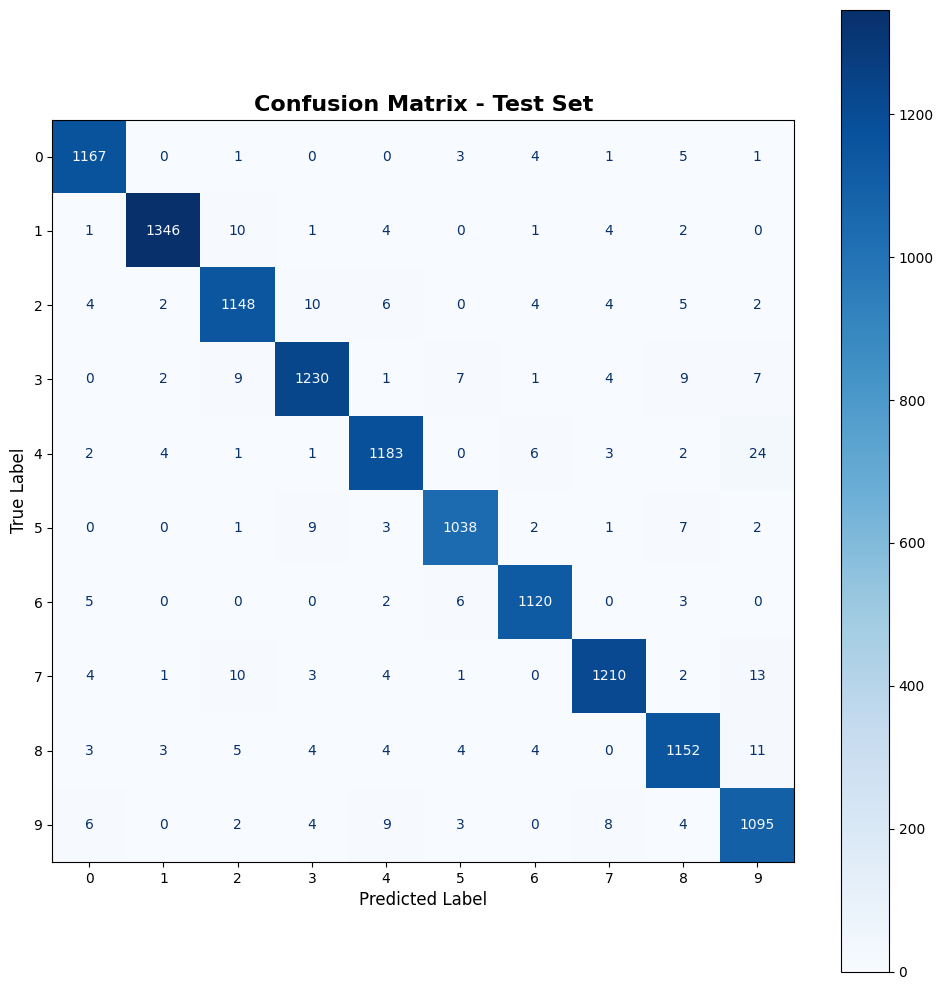

혼동 행렬 분석

각 숫자별 정확도:
숫자 0: 1167/1182 = 98.73%
숫자 1: 1346/1369 = 98.32%
숫자 2: 1148/1185 = 96.88%
숫자 3: 1230/1270 = 96.85%
숫자 4: 1183/1226 = 96.49%
숫자 5: 1038/1063 = 97.65%
숫자 6: 1120/1136 = 98.59%
숫자 7: 1210/1248 = 96.96%
숫자 8: 1152/1190 = 96.81%
숫자 9: 1095/1131 = 96.82%

가장 많이 혼동된 경우 (Top 5):
실제 4 → 예측 9: 24회
실제 7 → 예측 9: 13회
실제 8 → 예측 9: 11회
실제 7 → 예측 2: 10회
실제 2 → 예측 3: 10회


In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 혼동 행렬 계산
cm = confusion_matrix(y_test, y_test_pred)

# 혼동 행렬 시각화
fig, ax = plt.subplots(figsize=(10, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=range(10))
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title('Confusion Matrix - Test Set', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()

# 혼동 행렬 통계 출력
print("=" * 60)
print("혼동 행렬 분석")
print("=" * 60)
print(f"\n각 숫자별 정확도:")
for digit in range(10):
    correct = cm[digit, digit]
    total = cm[digit, :].sum()
    accuracy = correct / total * 100
    print(f"숫자 {digit}: {correct}/{total} = {accuracy:.2f}%")

# 가장 많이 혼동된 경우 찾기
print(f"\n가장 많이 혼동된 경우 (Top 5):")
confusion_pairs = []
for i in range(10):
    for j in range(10):
        if i != j and cm[i, j] > 0:
            confusion_pairs.append((cm[i, j], i, j))
confusion_pairs.sort(reverse=True)

for count, true_label, pred_label in confusion_pairs[:5]:
    print(f"실제 {true_label} → 예측 {pred_label}: {count}회")

# 훈련된 모델 저장

In [19]:
import joblib

# 훈련된 모델 저장
model_path = '../models/mnist_ml_model.pkl'
joblib.dump(final_clf, model_path)

print("=" * 60)
print("✓ 모델 저장 완료!")
print("=" * 60)
print(f"모델 경로: {model_path}")
print(f"모델 타입: {type(final_clf).__name__}")
print(f"테스트 정확도: {test_accuracy:.4f}")
print("=" * 60)

✓ 모델 저장 완료!
모델 경로: ../models/mnist_ml_model.pkl
모델 타입: XGBClassifier
테스트 정확도: 0.9741


# 예측 생성

In [20]:
"""# test.csv를 로드하고 예측 수행 (평가를 위한 레이블 없음)
test_data = pd.read_csv("test.csv")
print(f"테스트 데이터 크기: {test_data.shape}")

# 예측 수행
y_pred = final_clf.predict(test_data)

# 예측을 CSV로 저장
submission = pd.DataFrame(y_pred, columns=["Label"])
submission.index += 1
submission.index.name = "ImageId"
submission.to_csv("submission.csv", index=True)

print(f"\n예측이 'submission.csv'에 저장되었습니다")
print(f"예측 개수: {len(y_pred)}")
print(f"\n예측된 레이블 분포:")
print(pd.Series(y_pred).value_counts().sort_index())"""

'# test.csv를 로드하고 예측 수행 (평가를 위한 레이블 없음)\ntest_data = pd.read_csv("test.csv")\nprint(f"테스트 데이터 크기: {test_data.shape}")\n\n# 예측 수행\ny_pred = final_clf.predict(test_data)\n\n# 예측을 CSV로 저장\nsubmission = pd.DataFrame(y_pred, columns=["Label"])\nsubmission.index += 1\nsubmission.index.name = "ImageId"\nsubmission.to_csv("submission.csv", index=True)\n\nprint(f"\n예측이 \'submission.csv\'에 저장되었습니다")\nprint(f"예측 개수: {len(y_pred)}")\nprint(f"\n예측된 레이블 분포:")\nprint(pd.Series(y_pred).value_counts().sort_index())'